In [1]:
import os
import pandas as pd
import numpy as np

import kagglehub

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

/Users/veronica/Desktop/Bootcamp/finalproject/corals/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("mehrdat/coral-reef-global-bleaching")
print("Path to dataset files:", path)

Path to dataset files: /Users/veronica/.cache/kagglehub/datasets/mehrdat/coral-reef-global-bleaching/versions/2


In [3]:
print(os.listdir(path))

coral = os.path.join(path, "coral.csv")
coral = pd.read_csv(coral)

coral

['coral.csv', 'coral_whole.csv']


/var/folders/yz/shh48k7s5kg3qtp0x9hzjb6c0000gn/T/ipykernel_91544/4095051431.py:4: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  coral = pd.read_csv(coral)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.1630,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.5750,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.3690,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.7600,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.7690,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41356,15446,10310562,Reef_Check,-8.3651,116.0844,Pacific,116.5.3.9E.8.21.54.4S,Central Indo-Pacific,Lesser Sunda Islands and Savu Sea,Indonesia,...,8,1,2.09,1.49,9,0.63,2019-05-28,nd,nd,nd
41357,15456,10310527,Reef_Check,-8.3473,116.0503,Pacific,116.3.1.1E.8.20.50.2S,Central Indo-Pacific,Lesser Sunda Islands and Savu Sea,Indonesia,...,8,1,2,1.29,8.01,0.65,2019-05-16,nd,nd,nd
41358,15456,10310527,Reef_Check,-8.3473,116.0503,Pacific,116.3.1.1E.8.20.50.2S,Central Indo-Pacific,Lesser Sunda Islands and Savu Sea,Indonesia,...,8,1,2,1.29,8.01,0.65,2019-05-16,nd,nd,nd
41359,15457,10310536,Reef_Check,-8.3445,116.0629,Pacific,116.3.46.548E.8.20.40.236S,Central Indo-Pacific,Lesser Sunda Islands and Savu Sea,Indonesia,...,8,1,2,1.29,8.01,0.65,2019-05-29,nd,nd,nd


In [4]:
coral["Bleaching_Level"].value_counts()

Bleaching_Level
Population    22531
nd            18830
Name: count, dtype: int64

In [5]:
coral.columns

Index(['Site_ID', 'Sample_ID', 'Data_Source', 'Latitude_Degrees',
       'Longitude_Degrees', 'Ocean_Name', 'Reef_ID', 'Realm_Name',
       'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name', 'Distance_to_Shore', 'Exposure',
       'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year',
       'Depth_m', 'Substrate_Name', 'Percent_Cover', 'Bleaching_Level',
       'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Freq

In [6]:
columns_to_drop = [
    'Site_ID', 'Sample_ID', 'Data_Source', 'Reef_ID', 'Country_Name', 'State_Island_Province_Name', 
    'City_Town_Name', 'Site_Name', 'Date_Day', 'Date_Month', 'Date_Year', 'Substrate_Name', 
    'Temperature_Minimum', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_Standard_Deviation', 
    'SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 
    'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMean', 'TSA_Standard_Deviation', 'TSA_Minimum', 
    'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMean', 'TSA_FrequencyMax', 'TSA_DHW_Standard_Deviation', 
    'TSA_DHWMax', 'TSA_DHWMean', 'Site_Comments', 'Bleaching_Comments', 'Sample_Comments', 'ClimSST', 
    'SSTA_Mean', 'TSA_Mean', 'Percent_Cover', 'Temperature_Mean'
]

coral = coral.drop(columns=columns_to_drop)

In [7]:
coral.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Latitude_Degrees     41361 non-null  float64
 1   Longitude_Degrees    41361 non-null  float64
 2   Ocean_Name           41361 non-null  object 
 3   Realm_Name           41361 non-null  object 
 4   Ecoregion_Name       41361 non-null  object 
 5   Distance_to_Shore    41361 non-null  object 
 6   Exposure             41361 non-null  object 
 7   Turbidity            41361 non-null  object 
 8   Cyclone_Frequency    41361 non-null  float64
 9   Depth_m              41361 non-null  object 
 10  Bleaching_Level      41361 non-null  object 
 11  Percent_Bleaching    41361 non-null  object 
 12  Temperature_Kelvin   41361 non-null  object 
 13  Temperature_Maximum  41361 non-null  object 
 14  Windspeed            41361 non-null  object 
 15  SSTA                 41361 non-null 

### DATA CLEANING

In [8]:
## CORAL

coral.isnull().sum()

Latitude_Degrees       0
Longitude_Degrees      0
Ocean_Name             0
Realm_Name             0
Ecoregion_Name         0
Distance_to_Shore      0
Exposure               0
Turbidity              0
Cyclone_Frequency      0
Depth_m                0
Bleaching_Level        0
Percent_Bleaching      0
Temperature_Kelvin     0
Temperature_Maximum    0
Windspeed              0
SSTA                   0
SSTA_Maximum           0
SSTA_Frequency         0
SSTA_DHW               0
TSA                    0
TSA_Maximum            0
TSA_Frequency          0
TSA_DHW                0
Date                   0
dtype: int64

In [9]:
coral.duplicated().sum()

np.int64(14438)

In [10]:
# TREATING 'nd' ACCORDING TO DOCUMENTATION

coral["Bleaching_Level"] = coral["Bleaching_Level"].replace("nd", "Colony")
coral.replace('nd', np.nan, inplace=True)

In [11]:
coral["Bleaching_Level"].value_counts()

Bleaching_Level
Population    22531
Colony        18830
Name: count, dtype: int64

## Date

In [12]:
# Parse date as datetime and extract year as a separate column
# Note: keeping date as datetime so temporal analysis works correctly
coral['Date'] = pd.to_datetime(coral['Date'], format='%Y-%m-%d')
coral['Year'] = coral['Date'].dt.year

print('Date range:', coral['Date'].min(), '→', coral['Date'].max())
print('Year range:', coral['Year'].min(), '→', coral['Year'].max())

Date range: 1980-06-15 00:00:00 → 2020-08-15 00:00:00
Year range: 1980 → 2020


In [13]:
coral.columns = coral.columns.str.lower()

In [14]:
coral["depth_m"].head(50)

0        10
1        14
2         7
3      9.02
4     12.50
5      11.5
6      27.7
7       NaN
8      4.05
9       NaN
10     4.82
11      9.8
12        9
13    14.51
14        3
15       15
16       12
17      NaN
18     3.75
19     16.5
20      8.8
21     14.9
22      8.3
23    11.45
24      3.4
25      9.8
26     11.3
27    10.55
28    16.05
29    15.25
30        7
31       18
32     5.35
33    10.35
34     10.4
35     14.9
36       10
37      9.4
38       10
39      8.2
40     20.9
41      9.9
42      NaN
43       15
44      7.6
45     8.05
46    14.15
47     5.35
48     17.7
49     16.1
Name: depth_m, dtype: object

In [15]:
columns_to_convert = [
    'distance_to_shore', 'turbidity', 'depth_m', 
    'percent_bleaching', 'ssta', 'ssta_maximum', 'ssta_frequency', 
    'ssta_dhw', 'tsa', 'tsa_maximum', 'tsa_frequency', 
    'tsa_dhw', 'temperature_maximum', 'windspeed', 'temperature_kelvin'
]

coral[columns_to_convert] = coral[columns_to_convert].apply(pd.to_numeric, errors='coerce')

In [16]:
coral = coral.rename(columns={
    'temperature_kelvin': 'sst_kelvin',   # keep original name to remind us to convert
    'temperature_maximum': 'sst_maximum_kelvin',
    'latitude_degrees': 'latitude',
    'longitude_degrees': 'longitude',
    'ocean_name': 'ocean',
    'realm_name': 'realm',
    'ecoregion_name': 'ecoregion'
})

#### Temperature conversion — Kelvin → Celsius

The raw dataset stores temperature in Kelvin (`temperature_kelvin`). 
We must convert to Celsius before any analysis or modelling, otherwise 
correlation with bleaching will be misleading and model coefficients will be wrong.

In [17]:
# FIX: Convert SST and SST_maximum from Kelvin to Celsius
coral['sst'] = coral['sst_kelvin'] - 273.15
coral['sst_maximum'] = coral['sst_maximum_kelvin'] - 273.15

# Drop the Kelvin columns — no longer needed
coral = coral.drop(columns=['sst_kelvin', 'sst_maximum_kelvin'])

print('SST range (°C):', coral['sst'].min().round(2), '→', coral['sst'].max().round(2))
print('Expected: ~14°C (cold upwellings) to ~37°C (Arabian Gulf/Red Sea)')
print()
coral[['sst', 'sst_maximum']].describe().round(2)

SST range (°C): 13.89 → 37.29
Expected: ~14°C (cold upwellings) to ~37°C (Arabian Gulf/Red Sea)



,sst,sst_maximum
count,41213.00,41229.00
mean,28.18,31.97
std,1.97,1.32
min,13.89,26.98
25%,27.12,31.26
50%,28.50,31.95
75%,29.52,32.62
max,37.29,39.99


#### Null Values

In [18]:
coral.isnull().sum()

latitude                0
longitude               0
ocean                   0
realm                   0
ecoregion               3
distance_to_shore       2
exposure                0
turbidity               6
cyclone_frequency       0
depth_m              1799
bleaching_level         0
percent_bleaching    6846
windspeed             129
ssta                  148
ssta_maximum          132
ssta_frequency        148
ssta_dhw              148
tsa                   148
tsa_maximum           132
tsa_frequency         148
tsa_dhw               148
date                    0
year                    0
sst                   148
sst_maximum           132
dtype: int64

In [19]:
## ECOREGION — drop rows with missing ecoregion (no geographic reference)
coral = coral.dropna(subset=['ecoregion'])

In [20]:
## PERCENT BLEACHING — drop rows with missing target variable
coral = coral.dropna(subset=['percent_bleaching'])

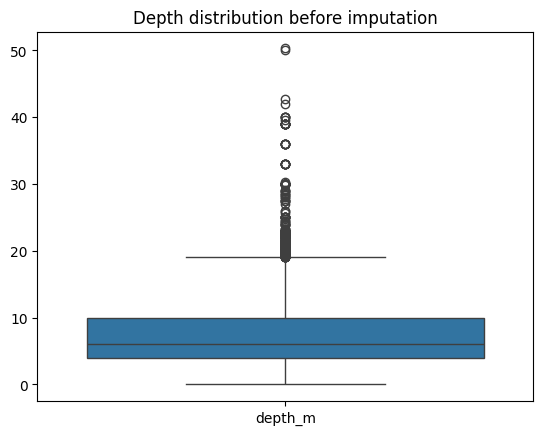

In [21]:
## DEPTH — median imputation (robust to skew)
sns.boxplot(data=coral[['depth_m']])
plt.title('Depth distribution before imputation')
plt.show()

coral['depth_m'] = coral['depth_m'].fillna(coral['depth_m'].median())

<Axes: xlabel='depth_m', ylabel='Count'>

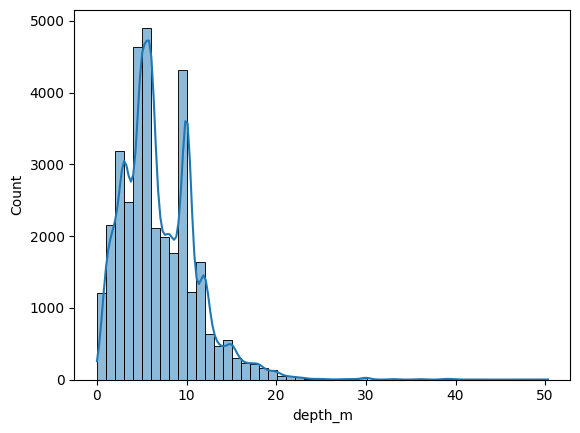

In [22]:
sns.histplot(coral["depth_m"], bins=50, kde=True)

In [23]:
## DISTANCE TO SHORE — mean imputation
print(coral['distance_to_shore'].describe())
coral['distance_to_shore'] = coral['distance_to_shore'].fillna(coral['distance_to_shore'].mean())

count     34510.000000
mean       3672.325921
std       13385.037571
min           3.200000
25%         126.240000
50%         476.030000
75%        1837.212500
max      299218.500000
Name: distance_to_shore, dtype: float64


In [24]:
## TURBIDITY — mean imputation
print(coral['turbidity'].describe())
coral['turbidity'] = coral['turbidity'].fillna(coral['turbidity'].mean())

count    34506.000000
mean         0.075545
std          0.061991
min          0.000000
25%          0.039600
50%          0.057000
75%          0.084200
max          1.284500
Name: turbidity, dtype: float64


#### IterativeImputer for remaining numerical columns

⚠️ **Leakage note:** This imputer is fitted on the full dataset here for EDA/cleaning purposes. 
When building the predictive model, re-fit the imputer **only on the training split** 
and use `transform()` on the test split — never `fit_transform()` on the full data in the modelling notebook.

In [25]:
numerical_columns = coral.select_dtypes(include=['float64', 'int64']).columns
# Exclude 'year' from imputation — it's a derived date field, not a feature to impute
numerical_columns = numerical_columns.drop('year') if 'year' in numerical_columns else numerical_columns

coral_numerical = coral[numerical_columns]

imputer = IterativeImputer(max_iter=10, random_state=42)
coral.loc[:, numerical_columns] = imputer.fit_transform(coral_numerical)

print('Nulls after imputation:')
print(coral.isnull().sum())

Nulls after imputation:
latitude             0
longitude            0
ocean                0
realm                0
ecoregion            0
distance_to_shore    0
exposure             0
turbidity            0
cyclone_frequency    0
depth_m              0
bleaching_level      0
percent_bleaching    0
windspeed            0
ssta                 0
ssta_maximum         0
ssta_frequency       0
ssta_dhw             0
tsa                  0
tsa_maximum          0
tsa_frequency        0
tsa_dhw              0
date                 0
year                 0
sst                  0
sst_maximum          0
dtype: int64


In [26]:
coral.isnull().sum()

latitude             0
longitude            0
ocean                0
realm                0
ecoregion            0
distance_to_shore    0
exposure             0
turbidity            0
cyclone_frequency    0
depth_m              0
bleaching_level      0
percent_bleaching    0
windspeed            0
ssta                 0
ssta_maximum         0
ssta_frequency       0
ssta_dhw             0
tsa                  0
tsa_maximum          0
tsa_frequency        0
tsa_dhw              0
date                 0
year                 0
sst                  0
sst_maximum          0
dtype: int64

In [27]:
## CHECK AND REMOVE DUPLICATES
print('Duplicates found:', coral.duplicated().sum())
coral = coral.drop_duplicates()

Duplicates found: 11309


In [28]:
coral

,latitude,longitude,ocean,realm,ecoregion,distance_to_shore,exposure,turbidity,cyclone_frequency,depth_m,...,ssta_frequency,ssta_dhw,tsa,tsa_maximum,tsa_frequency,tsa_dhw,date,year,sst,sst_maximum
0,23.1630,-82.5260,Atlantic,Tropical Atlantic,Cuba and Cayman Islands,8519.23,Exposed,0.0287,49.90,10.00,...,0.0,0.00,-0.80,1.83,0.00,0.00,2005-09-15,2005,28.90,31.54
1,-17.5750,-149.7833,Pacific,Eastern Indo-Pacific,Society Islands French Polynesia,1431.62,Exposed,0.0262,51.20,14.00,...,0.5,0.26,1.29,3.00,0.25,0.26,1991-03-15,1991,30.15,31.86
2,18.3690,-64.5640,Atlantic,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,182.33,Exposed,0.0429,61.52,7.00,...,16.0,0.00,-2.64,2.31,7.00,0.00,2006-01-15,2006,26.03,30.99
3,17.7600,-64.5680,Atlantic,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,313.13,Exposed,0.0424,65.39,9.02,...,22.0,0.00,-2.27,2.19,3.00,0.00,2006-04-15,2006,26.46,30.92
4,17.7690,-64.5830,Atlantic,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,792.00,Exposed,0.0424,65.39,12.50,...,16.0,0.00,-2.19,1.87,3.00,0.00,2006-04-15,2006,26.55,30.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35038,10.1167,99.8444,Pacific,Central Indo-Pacific,Gulf of Thailand,73.88,Exposed,0.0565,50.27,5.00,...,2.0,1.37,1.26,3.35,1.00,1.33,2014-05-27,2014,31.64,33.74
35040,18.3350,-64.8486,Atlantic,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,49.16,Sheltered,0.0586,85.57,3.00,...,12.0,10.14,0.21,1.76,5.00,6.22,2005-10-23,2005,28.96,30.52
35042,-13.5002,47.8825,Indian,Western Indo-Pacific,North Madagascar,8768.03,Sometimes,0.0628,35.71,14.00,...,9.0,5.81,0.59,2.46,4.00,4.44,2016-04-18,2016,30.30,32.17
35043,24.5019,-81.6328,Atlantic,Tropical Atlantic,Bahamas and Florida Keys,8170.00,Exposed,0.1203,58.42,4.00,...,25.0,51.11,3.91,6.19,25.00,50.63,2015-09-10,2015,30.61,32.89


#### Final column selection

In [29]:
# Select and reorder final columns
# year is added after date for easy temporal filtering
coral = coral[[
    'date', 'year', 'latitude', 'longitude',
    'ocean', 'realm', 'ecoregion',
    'distance_to_shore', 'exposure', 'depth_m', 'turbidity',
    'bleaching_level', 'percent_bleaching',
    'cyclone_frequency', 'windspeed',
    'sst', 'sst_maximum',
    'ssta', 'ssta_maximum', 'ssta_frequency',
    'tsa', 'tsa_maximum', 'tsa_frequency',
    'ssta_dhw', 'tsa_dhw'
]]

coral = coral.reset_index(drop=True)
print(coral.shape)
coral.info()

(23203, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23203 entries, 0 to 23202
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               23203 non-null  datetime64[ns]
 1   year               23203 non-null  int32         
 2   latitude           23203 non-null  float64       
 3   longitude          23203 non-null  float64       
 4   ocean              23203 non-null  object        
 5   realm              23203 non-null  object        
 6   ecoregion          23203 non-null  object        
 7   distance_to_shore  23203 non-null  float64       
 8   exposure           23203 non-null  object        
 9   depth_m            23203 non-null  float64       
 10  turbidity          23203 non-null  float64       
 11  bleaching_level    23203 non-null  object        
 12  percent_bleaching  23203 non-null  float64       
 13  cyclone_frequency  23203 non-null  float64       

#### Sanity check before saving

In [30]:
print('=== FINAL SANITY CHECK ===')
print(f'Shape: {coral.shape}')
print(f'Nulls: {coral.isnull().sum().sum()}')
print(f'Duplicates: {coral.duplicated().sum()}')
print(f'Date type: {coral["date"].dtype}')
print(f'SST range: {coral["sst"].min():.1f}°C → {coral["sst"].max():.1f}°C')
print(f'Bleaching range: {coral["percent_bleaching"].min()}% → {coral["percent_bleaching"].max()}%')
print(f'Year range: {coral["year"].min()} → {coral["year"].max()}')
print()
coral.describe().round(2)

=== FINAL SANITY CHECK ===
Shape: (23203, 25)
Nulls: 0
Duplicates: 0
Date type: datetime64[ns]
SST range: 13.9°C → 37.3°C
Bleaching range: 0.0% → 100.0%
Year range: 1980 → 2020



,date,year,latitude,longitude,distance_to_shore,depth_m,turbidity,percent_bleaching,cyclone_frequency,windspeed,sst,sst_maximum,ssta,ssta_maximum,ssta_frequency,tsa,tsa_maximum,tsa_frequency,ssta_dhw,tsa_dhw
count,23203,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00,23203.00
mean,2008-06-05 05:55:25.380338944,2007.89,9.97,10.80,4077.38,7.24,0.07,13.04,52.84,4.79,28.29,31.97,0.29,3.44,7.62,-0.90,2.76,2.13,3.29,1.49
min,1980-06-15 00:00:00,1980.00,-28.86,-179.86,3.20,0.00,0.00,0.00,18.31,0.00,13.89,26.98,-4.26,0.00,0.00,-11.97,0.00,0.00,0.00,0.00
25%,2004-10-15 00:00:00,2004.00,2.82,-80.56,158.91,4.10,0.04,0.00,48.18,3.00,27.30,31.27,-0.21,2.78,3.00,-1.72,2.22,0.00,0.00,0.00
50%,2007-06-30 00:00:00,2007.00,16.37,-61.37,661.40,6.00,0.06,1.50,52.33,5.00,28.60,31.89,0.28,3.16,6.00,-0.65,2.52,1.00,1.47,0.00
75%,2013-02-18 00:00:00,2013.00,22.47,118.26,2386.61,10.00,0.08,13.20,57.11,6.00,29.62,32.60,0.79,3.68,11.00,0.18,3.00,3.00,4.61,1.37
max,2020-08-15 00:00:00,2020.00,35.31,179.96,299218.50,50.30,1.28,100.00,105.80,15.00,37.29,39.99,5.90,19.89,52.00,5.90,13.45,29.00,53.60,52.45
std,NaN,5.80,15.69,104.05,14436.08,4.42,0.06,22.99,8.09,2.01,1.95,1.24,0.85,1.17,6.19,1.67,0.97,3.12,5.03,4.03


In [33]:
coral.to_csv('../data/coral_clean.csv', index=False)
print('Saved to ../data/coral_clean.csv')

Saved to ../data/coral_clean.csv
